## Simple Chatbot Using LangGraph

In [11]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages

In [12]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [13]:
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [14]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('groq:openai/gpt-oss-120b', temperature=0.4)

In [15]:
def super_bot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

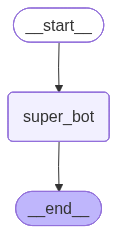

In [16]:
graph = StateGraph(State)
graph.add_node("super_bot", super_bot)
graph.add_edge(START, "super_bot")
graph.add_edge("super_bot", END)

graph_builder = graph.compile()

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [19]:
from langchain_core.messages import HumanMessage
graph_builder.invoke({"messages": [HumanMessage(content="Hi, I am Pawan and I like to make scalable Agentic AI Systems")]})

{'messages': [HumanMessage(content='Hi, I am Pawan and I like to make scalable Agentic AI Systems', additional_kwargs={}, response_metadata={}, id='b65cd129-0d4e-49e6-81ff-5d017e0eddc3'),
  AIMessage(content='Hello Pawan! 👋 It’s great to meet someone passionate about building scalable agentic AI systems. There’s a lot of exciting work happening in that space—whether you’re focusing on multi‑agent coordination, hierarchical planning, or robust deployment at scale.\n\nIf you’d like, we can dive into any of the following topics (or something else you have in mind):\n\n| Topic | What you’ll get |\n|-------|-----------------|\n| **Architectural patterns** | Overview of common designs (e.g., micro‑services, event‑driven pipelines, actor models) that help agents scale horizontally and stay resilient. |\n| **Communication protocols** | Comparison of REST, gRPC, message queues (Kafka, RabbitMQ), and pub/sub systems for inter‑agent messaging. |\n| **State management** | Strategies for persistent

## Streaming Response from LangGraph

In [23]:
for event in graph_builder.stream({"messages":"My Name is Pawan"}, stream_mode="updates"):
    print(event)

{'super_bot': {'messages': [AIMessage(content='Nice to meet you, Pawan! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "My Name is Pawan". Likely they want a response acknowledging. We should respond politely. No special instructions.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 76, 'total_tokens': 128, 'completion_time': 0.109981095, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.003472846, 'prompt_tokens_details': None, 'queue_time': 0.262866801, 'total_time': 0.113453941}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4b4b-79fc-73a1-9099-18f5d1052b05-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 52, 'total_tokens': 128, 'output_token_details': {'reasoning': 28}})]}}
